# Data Processing Report

Analysis of MTCNN-aligned face dataset produced by `process.py`.

Sources: CASIA-WebFace (training), LFW (held-out evaluation).
CelebA Kaggle dump lacked identity labels so was skipped — CASIA alone provides enough identities for Siamese training.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path

ROOT = Path('..').resolve()
df = pd.read_parquet(ROOT / 'process-data/manifest.parquet')
print(df['split'].value_counts())
print('Unique train identities:', df[df.split == 'train']['identity_id'].nunique())
df.head()

split
train    43278
lfw       7240
val       4473
Name: count, dtype: int64
Unique train identities: 1249


,path,identity_id,source,split
0,process-data/val/casia_0005123/0005123_237.jpg,casia_0005123,casia,val
1,process-data/val/casia_0005123/0005123_019.jpg,casia_0005123,casia,val
2,process-data/val/casia_0005123/0005123_200.jpg,casia_0005123,casia,val
3,process-data/val/casia_0005123/0005123_140.jpg,casia_0005123,casia,val
4,process-data/val/casia_0005123/0005123_075.jpg,casia_0005123,casia,val


## Folder exploration


In [2]:
# Folder-level exploration (per source): image shapes, total images, unique people.
from collections import Counter

for src in df['source'].unique():
    sub = df[df['source'] == src]
    shapes = Counter()
    for p in sub['path'].sample(min(200, len(sub)), random_state=0):
        with Image.open(ROOT / p) as im:
            shapes[im.size] += 1
    print(f'[{src}]')
    print(f'  shapes (sampled): {dict(shapes)}')
    print(f'  total images:     {len(sub):,}')
    print(f'  unique people:    {sub["identity_id"].nunique():,}')
    print()


[casia]
  shapes (sampled): {(160, 160): 200}
  total images:     47,751
  unique people:    1,249

[lfw]
  shapes (sampled): {(160, 160): 200}
  total images:     7,240
  unique people:    901



## Per-identity photo grid


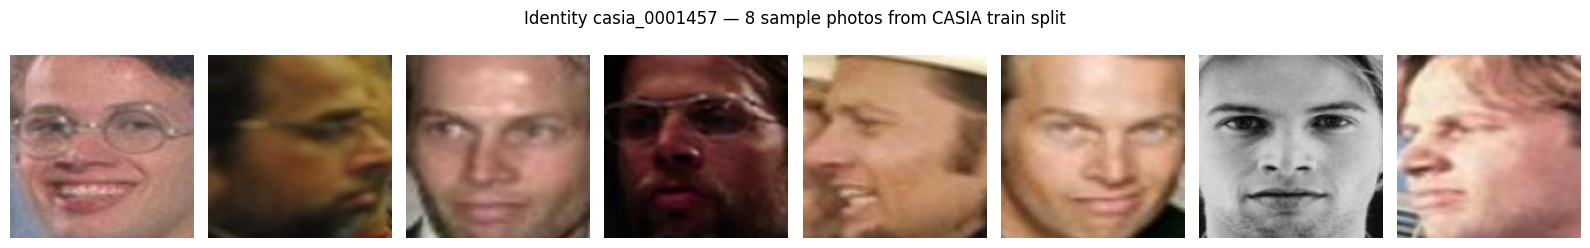

In [3]:
# Sample photos for one random identity (Kaggle-style per-person grid).
import random

rng = random.Random(0)
train = df[df.split == 'train']
counts = train['identity_id'].value_counts()
candidates = counts[counts >= 5].index.tolist()
pid = rng.choice(candidates)
samples = train[train.identity_id == pid].head(8)

n = len(samples)
fig, axes = plt.subplots(1, n, figsize=(2 * n, 2.5))
if n == 1:
    axes = [axes]
for ax, p in zip(axes, samples['path']):
    ax.imshow(Image.open(ROOT / p))
    ax.axis('off')
fig.suptitle(f'Identity {pid} — {n} sample photos from CASIA train split')
plt.tight_layout()
plt.show()


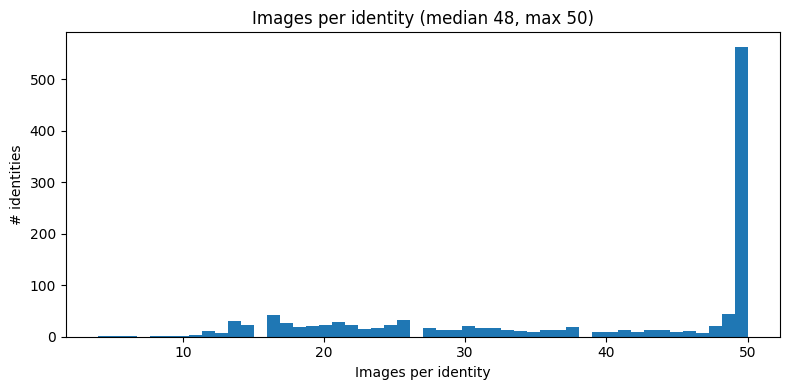

In [4]:
counts = df[df.split.isin(['train', 'val'])].groupby('identity_id').size()
plt.figure(figsize=(8, 4))
plt.hist(counts.values, bins=50)
plt.xlabel('Images per identity')
plt.ylabel('# identities')
plt.title(f'Images per identity (median {int(counts.median())}, max {int(counts.max())})')
plt.tight_layout()
plt.show()

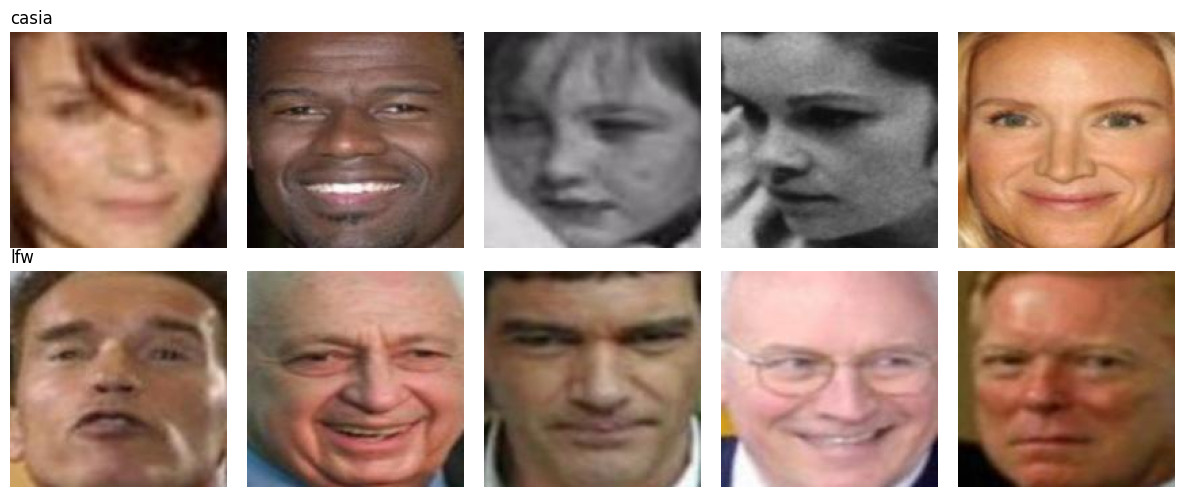

In [5]:
sources = df['source'].unique()
fig, axes = plt.subplots(len(sources), 5, figsize=(12, 2.5 * len(sources)))
if len(sources) == 1:
    axes = axes.reshape(1, -1)
for row, src in enumerate(sources):
    sample = df[df.source == src].sample(min(5, len(df[df.source == src])), random_state=0)
    for col, p in enumerate(sample['path']):
        img = Image.open(ROOT / p)
        axes[row, col].imshow(img)
        axes[row, col].axis('off')
    axes[row, 0].set_title(src, loc='left')
plt.tight_layout()
plt.show()

In [6]:
fail_path = ROOT / 'process-data/alignment_failures.csv'
if fail_path.exists():
    fail = pd.read_csv(fail_path)
else:
    fail = pd.DataFrame()
total_attempts = len(df) + len(fail)
rate = len(fail) / total_attempts if total_attempts else 0
print(f'Aligned: {len(df)}')
print(f'Failed:  {len(fail)}')
print(f'Rate:    {rate:.2%}')

Aligned: 54991
Failed:  0
Rate:    0.00%


## Split summary

- **train** — used to train the embedding network (CASIA identities)
- **val** — held-out images of the same identities as train (for in-loop sanity)
- **lfw** — held-out identities for verification benchmark (different distribution)
